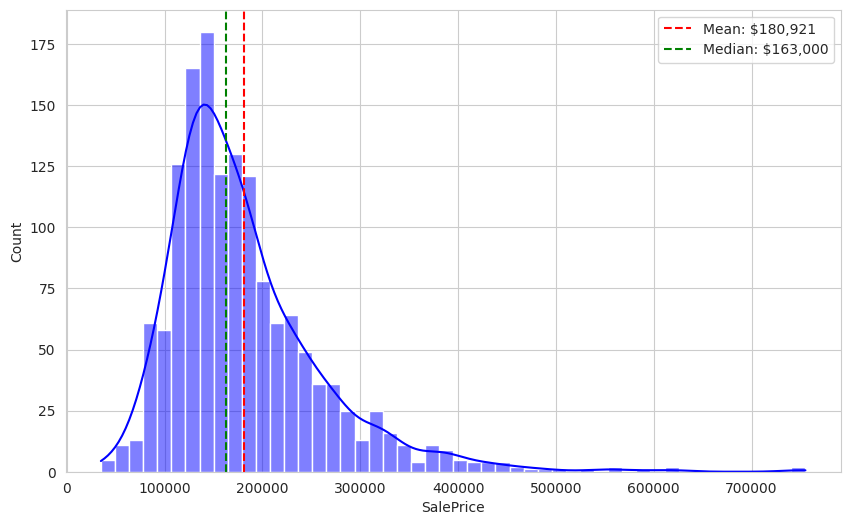

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, r2_score
from scipy.special import boxcox1p
# Импорты из src
from src.preprocess import fill_missing_values, transform_skewed_features,analyze_outliers_iqr,get_saleprice_bounds

from sklearn.model_selection import train_test_split


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
test_ids = test['Id']
train=train.drop('Id',axis=1)
test=test.drop('Id',axis=1)
y = train['SalePrice']
train=train.drop('SalePrice',axis=1)
df = pd.concat([train, y], axis=1)


plt.figure(figsize=(10, 6))
sns.histplot(y, bins=50, kde=True, color='blue')
plt.axvline(y.mean(), color='red', linestyle='--', label=f'Mean: ${y.mean():,.0f}')
plt.axvline(y.median(), color='green', linestyle='--', label=f'Median: ${y.median():,.0f}')
plt.legend()


In [2]:
# Analyze the target variable: SalePrice
print("TARGET VARIABLE ANALYSIS: SalePrice")

# Basic statistics
print(f"Count: {y.count():,}")
print(f"Mean: ${y.mean():,.2f}")
print(f"Median: ${y.median():,.2f}")
print(f"Std Dev: ${y.std():,.2f}")
print(f"Min: ${y.min():,.2f}")
print(f"Max: ${y.max():,.2f}")
print(f"Skewness: {y.skew():.3f}")
print(f"Kurtosis: {y.kurtosis():.3f}")

TARGET VARIABLE ANALYSIS: SalePrice
Count: 1,460
Mean: $180,921.20
Median: $163,000.00
Std Dev: $79,442.50
Min: $34,900.00
Max: $755,000.00
Skewness: 1.883
Kurtosis: 6.536


Number of numerical features: 36

Numerical features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Highly skewed features (|skew| > 0.75): 21

Top 10 most skewed features:
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
dtype: float64


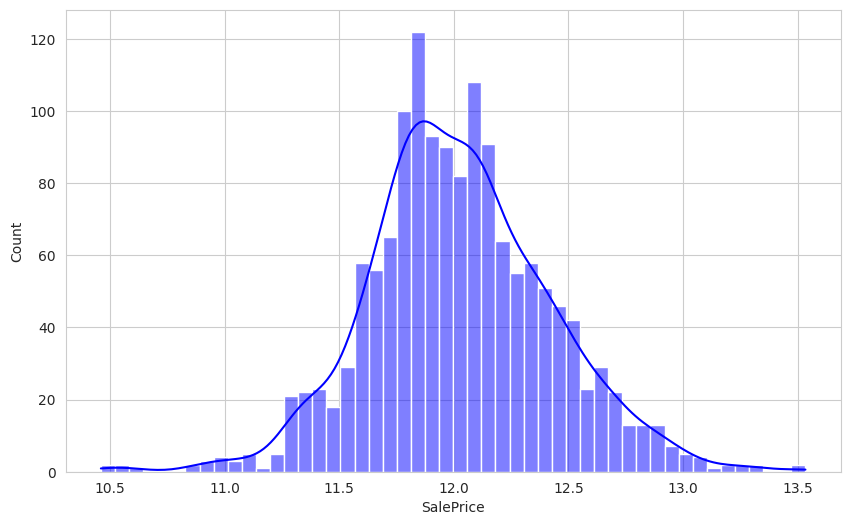

In [3]:
y_log = np.log1p(y)
plt.figure(figsize=(10,6))
sns.histplot(y_log,bins=50,kde=True,color='blue')

numerical_features = train.select_dtypes(include=[np.number]).columns
numeric_list = numerical_features.tolist()
print(f"Number of numerical features: {len(numeric_list)}")
print(f"\nNumerical features: {numeric_list}")
skewed_features = train[numeric_list].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_features = skewed_features[abs(skewed_features) > 0.75]
print()
print(f"Highly skewed features (|skew| > 0.75): {len(skewed_features)}")
print("\nTop 10 most skewed features:")
print(skewed_features.head(10))

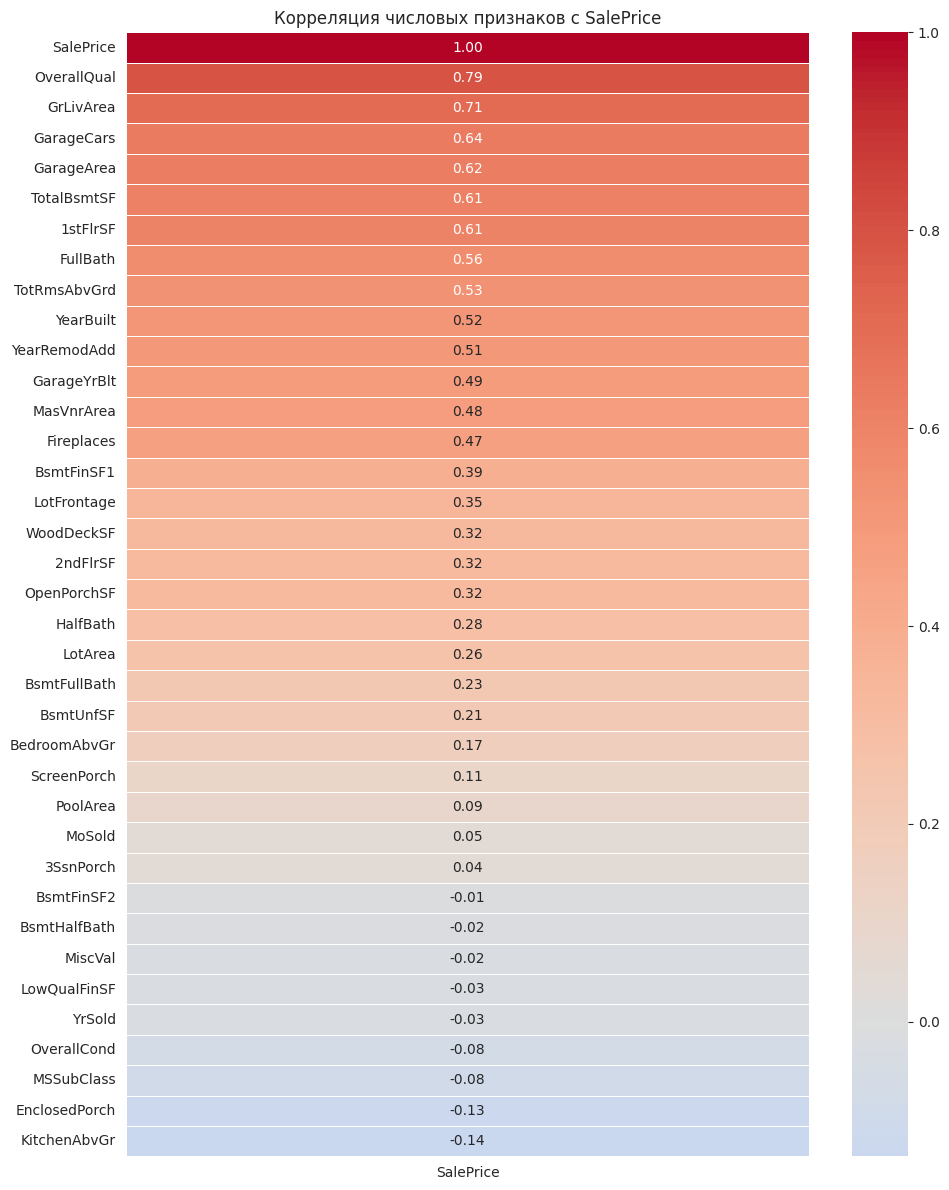

In [4]:

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

corr_with_price = corr_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Корреляция числовых признаков с SalePrice')
plt.tight_layout()
plt.show()

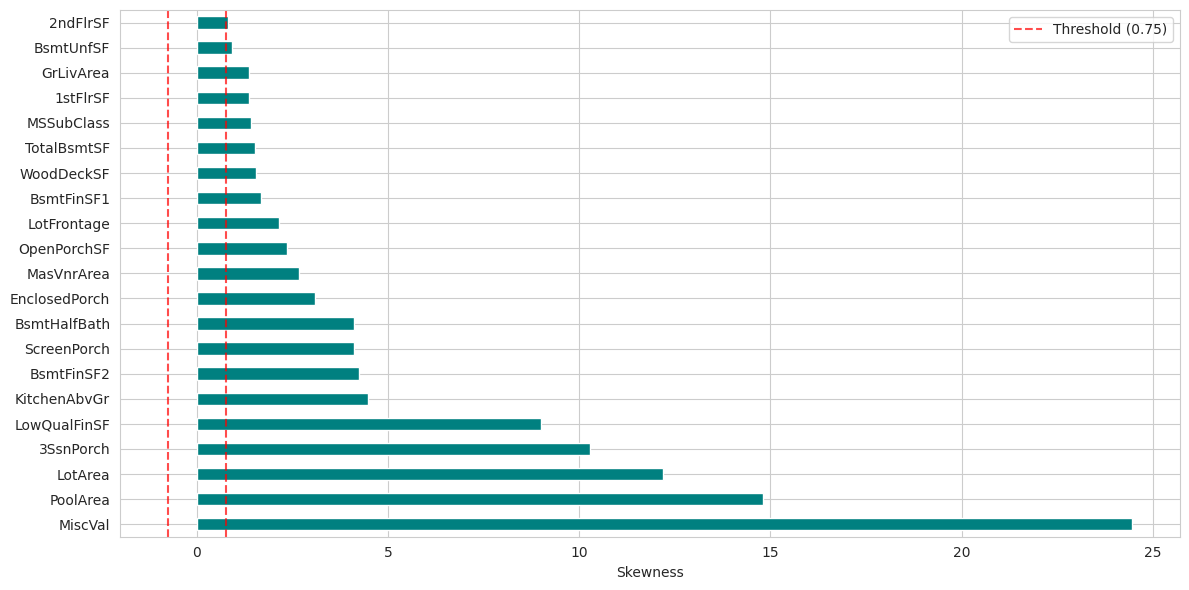

In [5]:


plt.figure(figsize=(12,6))
skewed_features.plot(kind='barh', color='teal')
plt.xlabel('Skewness')
plt.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='Threshold (0.75)')
plt.axvline(x=-0.75, color='red', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Можно логарифмировать скошенные влево(зеркально), а boxcox применть к признаком с положительной ассиметрией

/tmp/ipykernel_16582/885548276.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include=['object']).columns.tolist()
/tmp/ipykernel_16582/885548276.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='Set2')


Number of categorical features: 43

Top 10 highest cardinality features:
Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
dtype: int64


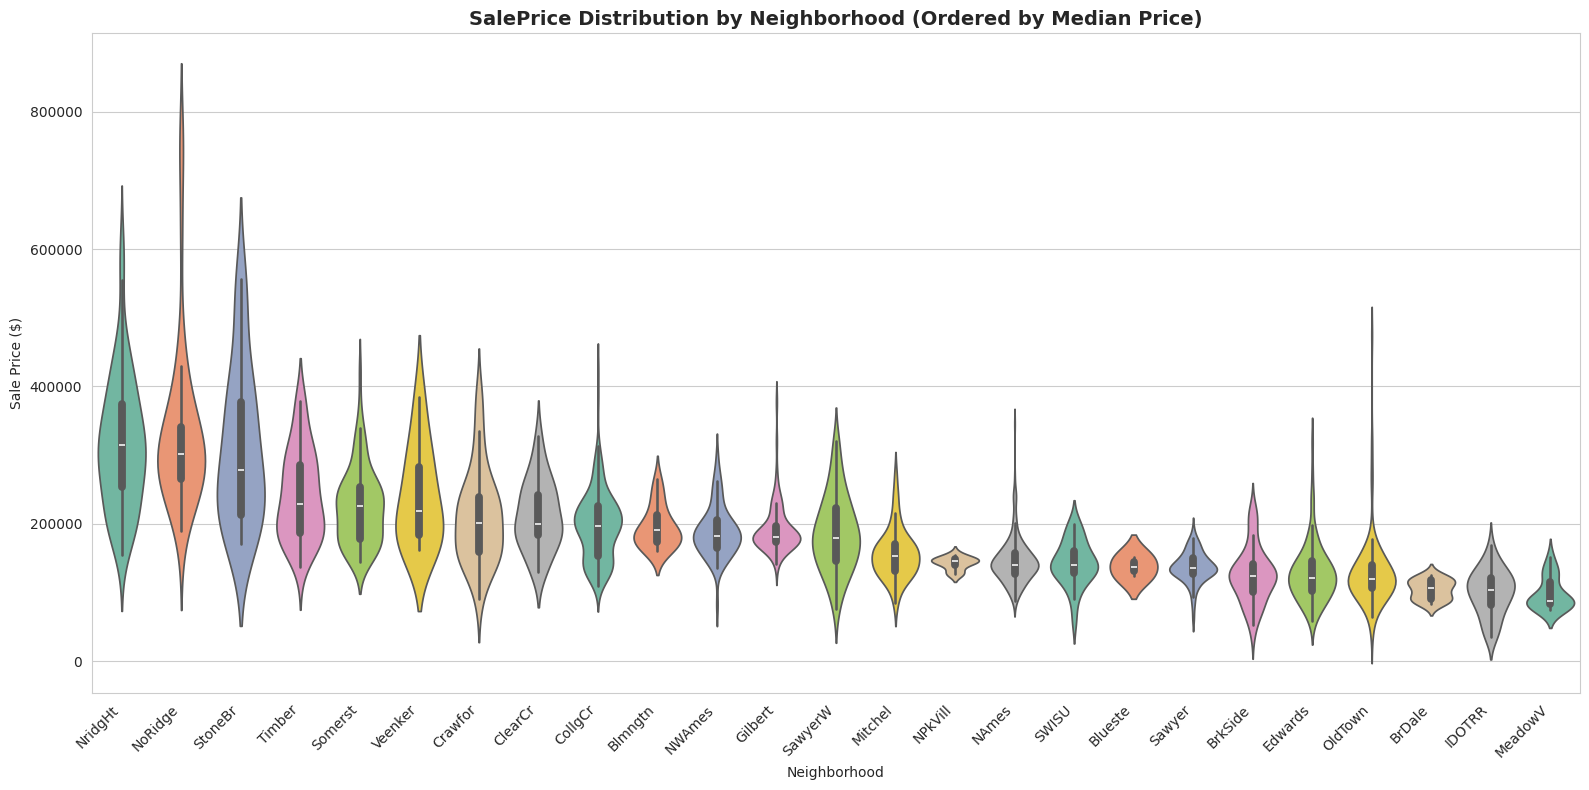

Neighborhood Statistics (Top 10 by Median Price):
                median           mean  count
Neighborhood                                
NridgHt       315000.0  316270.623377     77
NoRidge       301500.0  335295.317073     41
StoneBr       278000.0  310499.000000     25
Timber        228475.0  242247.447368     38
Somerst       225500.0  225379.837209     86
Veenker       218000.0  238772.727273     11
Crawfor       200624.0  210624.725490     51
ClearCr       200250.0  212565.428571     28
CollgCr       197200.0  197965.773333    150
Blmngtn       191000.0  194870.882353     17


In [6]:
categorical_features = train.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical features: {len(categorical_features)}")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
print(f"\nTop 10 highest cardinality features:")
print(cardinality.head(25))
plt.figure(figsize=(16, 8))
neighborhood_stats = df.groupby('Neighborhood')['SalePrice'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)


# Create violin plot
order = neighborhood_stats.index
sns.violinplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice Distribution by Neighborhood (Ordered by Median Price)', fontsize=14, fontweight='bold')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

print("Neighborhood Statistics (Top 10 by Median Price):")
print(neighborhood_stats.head(10))

/tmp/ipykernel_16582/2013960453.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', order=order, ax=axes[idx], palette='viridis')
/tmp/ipykernel_16582/2013960453.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', order=order, ax=axes[idx], palette='viridis')
/tmp/ipykernel_16582/2013960453.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='SalePrice', order=order, ax=axes[idx], palette='viridis')
/tmp/ipykernel_16582/2013960453.py:10: FutureWarn

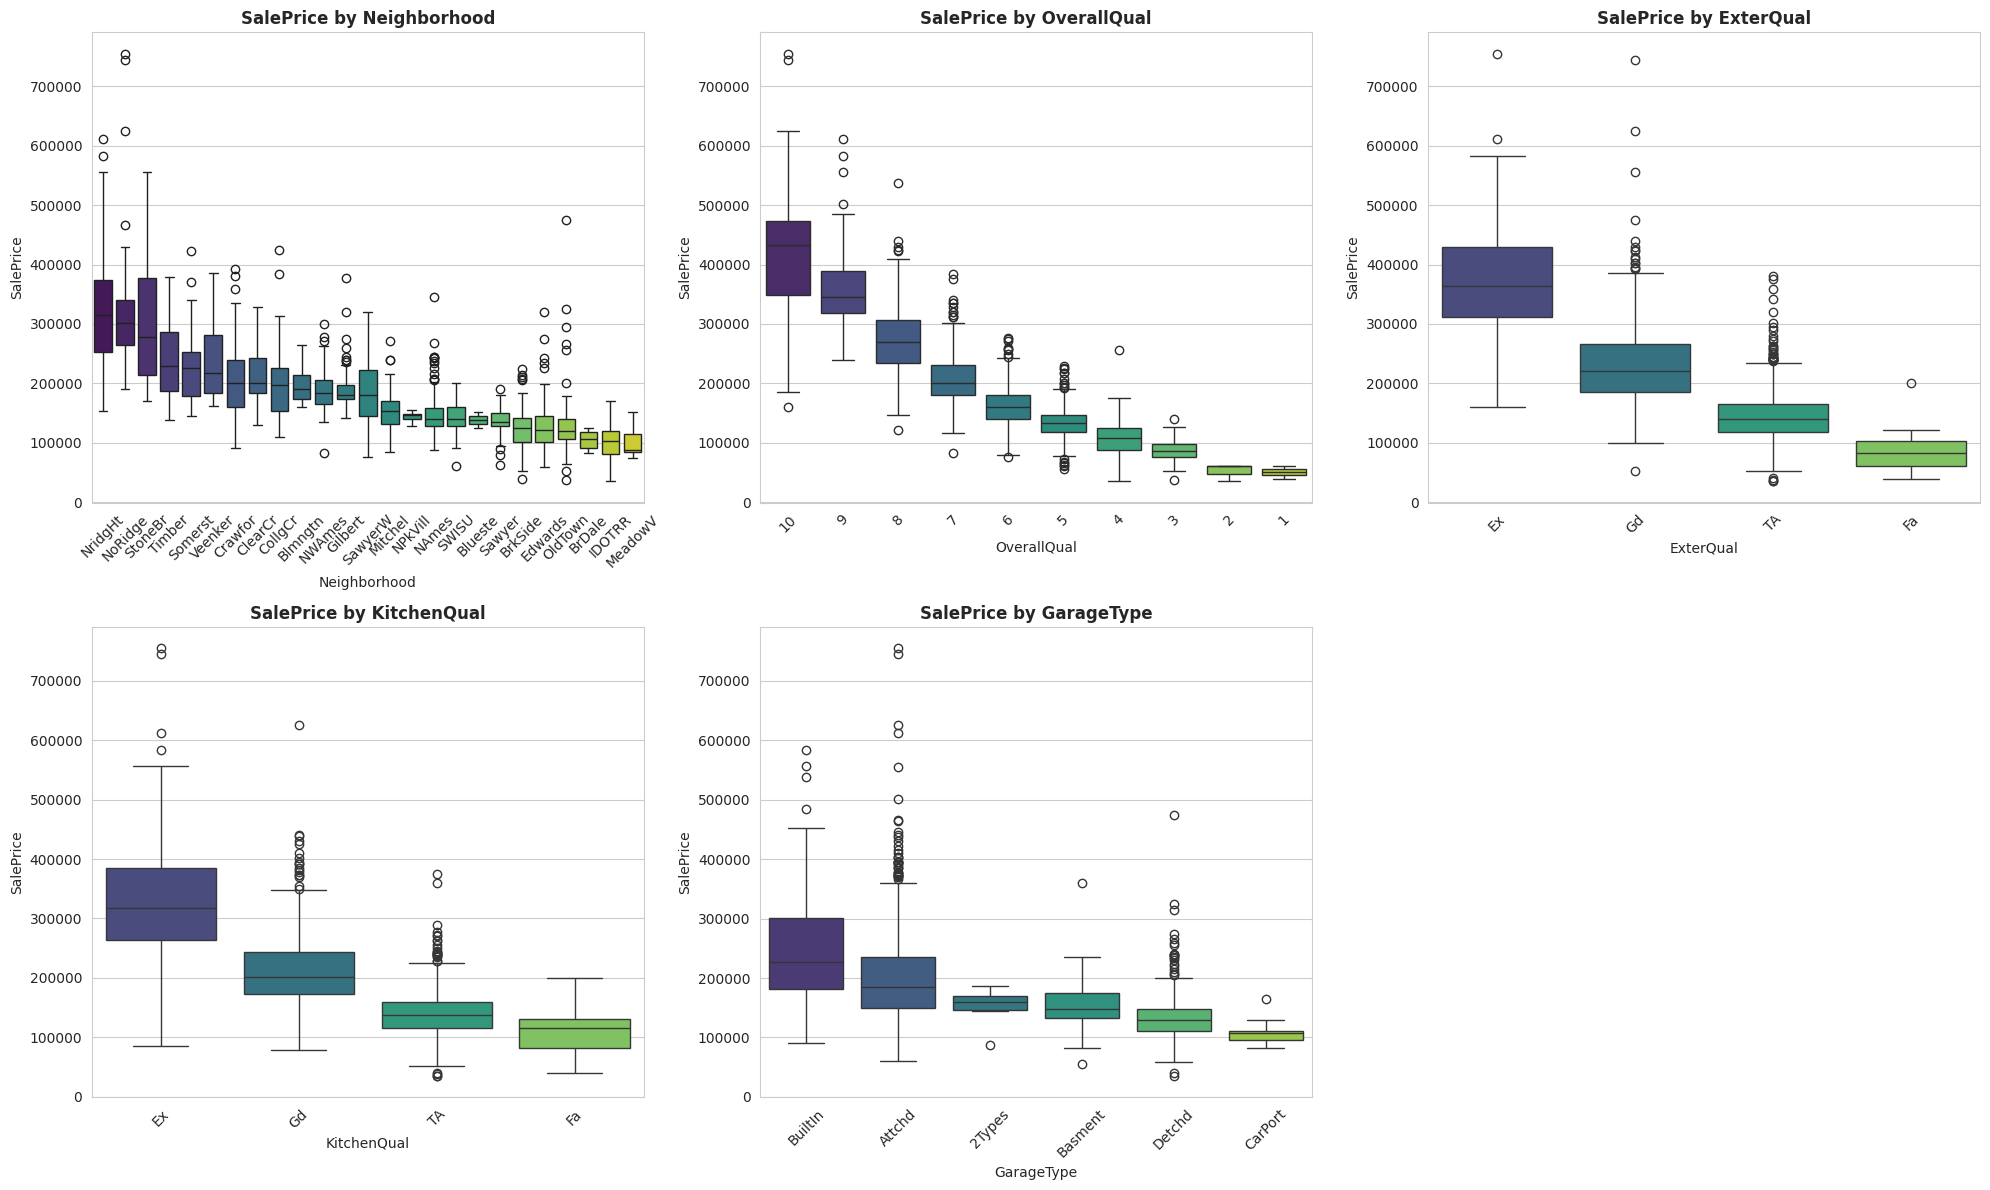

In [7]:
top_cat_features = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual', 'GarageType']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_cat_features):
    if idx < len(axes):
        # Boxplot
        order = df.groupby(feature)['SalePrice'].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=feature, y='SalePrice', order=order, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'SalePrice by {feature}', fontsize=12, fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45)

# Remove empty subplot
if len(top_cat_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


Разброс цен Neighborhood велик. Есть явные дорогие районы (Nridght, NoRidge, Stonebr) и дешёвые (MeadowV, ...). Много выбросов
Район нужно кодировать
OverallQual С ростом качества от 1 до 10 медианная цена монотонно возрастает. Линейная завсисимость. Категориальный признак, но уже кодированный
ExterQual (качество экстерьера). Категории: Po (плохое), Fa (удовлетворительное), TA (среднее), Gd (хорошее), Ex (отличное). Цена растёт с каждой ступенью качества. Порядковый признак
KitchenQual полная анология с ExterQuaдl. Их кодируем
GarageType Дома с пристроенным гаражом (Attchd) обычно дороже, чем с отдельным (Detchd).Отсутствие гаража (NaN в данных) соответствует самым низким ценам.

Features with missing values: 19

Top 10 features by missing count:
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55


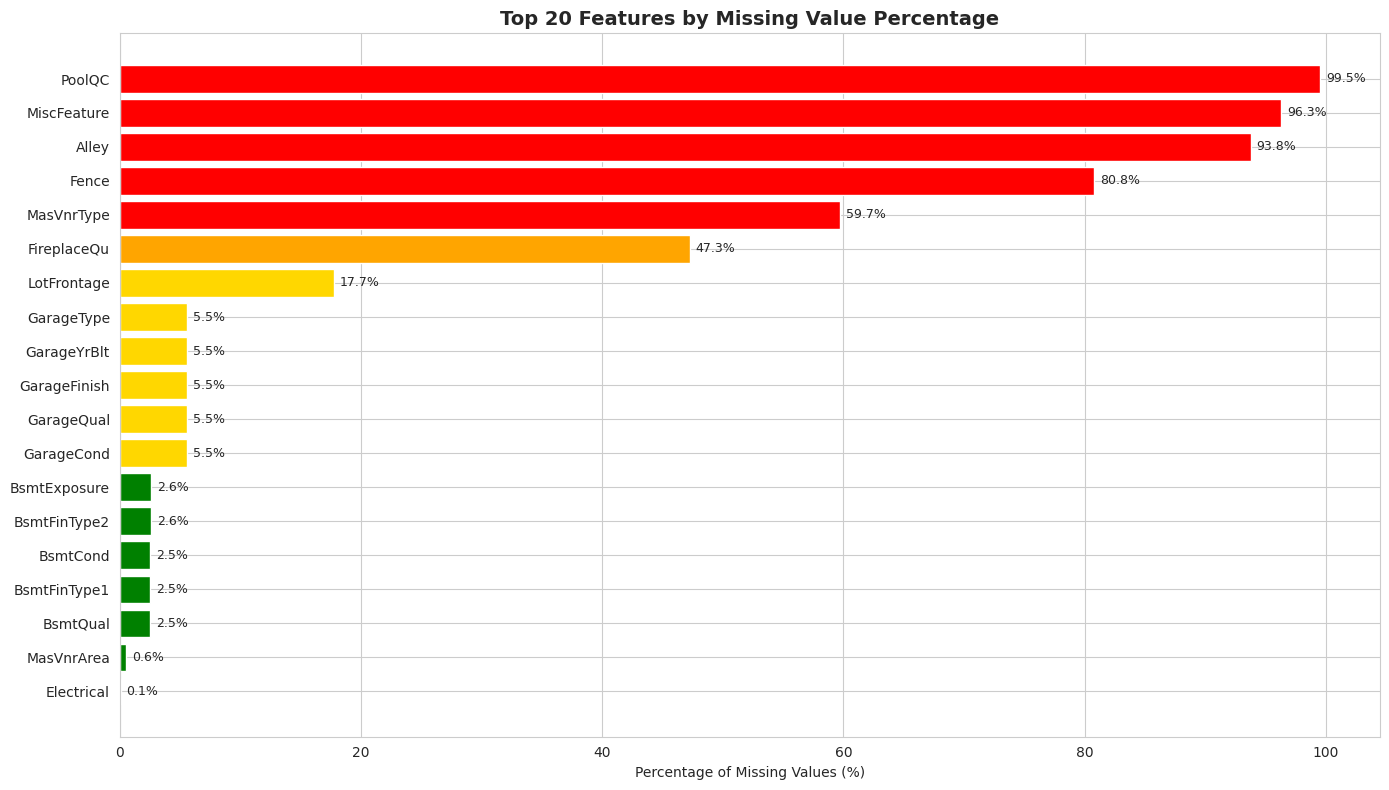

 Color Legend:
 Green: < 5% missing (minimal)
 Gold: 5-20% missing (moderate)
 Orange: 20-50% missing (significant)
 Red: > 50% missing (severe)


In [8]:
missing_data = train.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
missing_percent = (missing_data / len(train)) * 100

print(f"Features with missing values: {len(missing_data)}")
print(f"\nTop 10 features by missing count:")
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent.round(2)
})
print(missing_df.head(10))

plt.figure(figsize=(14, 8))
missing_df_top20 = missing_df.head(20)

colors = ['red' if x > 50 else 'orange' if x > 20 else 'gold' if x > 5 else 'green' for x in missing_df_top20['Missing %']]
bars = plt.barh(range(len(missing_df_top20)), missing_df_top20['Missing %'], color=colors)
plt.yticks(range(len(missing_df_top20)), missing_df_top20.index)
plt.xlabel('Percentage of Missing Values (%)')
plt.title('Top 20 Features by Missing Value Percentage', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add percentage labels
for i, (idx, row) in enumerate(missing_df_top20.iterrows()):
    plt.text(row['Missing %'] + 0.5, i, f'{row["Missing %"]:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(" Color Legend:")
print(" Green: < 5% missing (minimal)")
print(" Gold: 5-20% missing (moderate)")
print(" Orange: 20-50% missing (significant)")
print(" Red: > 50% missing (severe)")


У большинства признаков пропуски - это причина, по которой дом не имеет данный признак. Заполняем 0 или None

In [9]:
missing_numerical = [col for col in missing_data.index if col in numerical_features]
missing_categorical = [col for col in missing_data.index if col in categorical_features]

print(f"Missing numerical features: {len(missing_numerical)}")
print(f"Missing categorical features: {len(missing_categorical)}")

"""none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 
                 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
                 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']""" #категориальные признаки по которым видно, что у них пропуск Nones, 

"""print(f"\nFeatures where missing likely means 'None': {len([f for f in none_features if f in missing_data.index])}")"""

Missing numerical features: 3
Missing categorical features: 16


'print(f"\nFeatures where missing likely means \'None\': {len([f for f in none_features if f in missing_data.index])}")'

In [10]:
corr_matrix = df[numerical_features.tolist() + ['SalePrice']].corr()

# Get top correlations with SalePrice
price_correlations = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)
print("Top 15 Features Correlated with SalePrice:")
for feature, corr in price_correlations.head(15).items():
    print(f" {feature:20s}: {corr:6.3f}")
    

Top 15 Features Correlated with SalePrice:
 OverallQual         :  0.791
 GrLivArea           :  0.709
 GarageCars          :  0.640
 GarageArea          :  0.623
 TotalBsmtSF         :  0.614
 1stFlrSF            :  0.606
 FullBath            :  0.561
 TotRmsAbvGrd        :  0.534
 YearBuilt           :  0.523
 YearRemodAdd        :  0.507
 GarageYrBlt         :  0.486
 MasVnrArea          :  0.477
 Fireplaces          :  0.467
 BsmtFinSF1          :  0.386
 LotFrontage         :  0.352


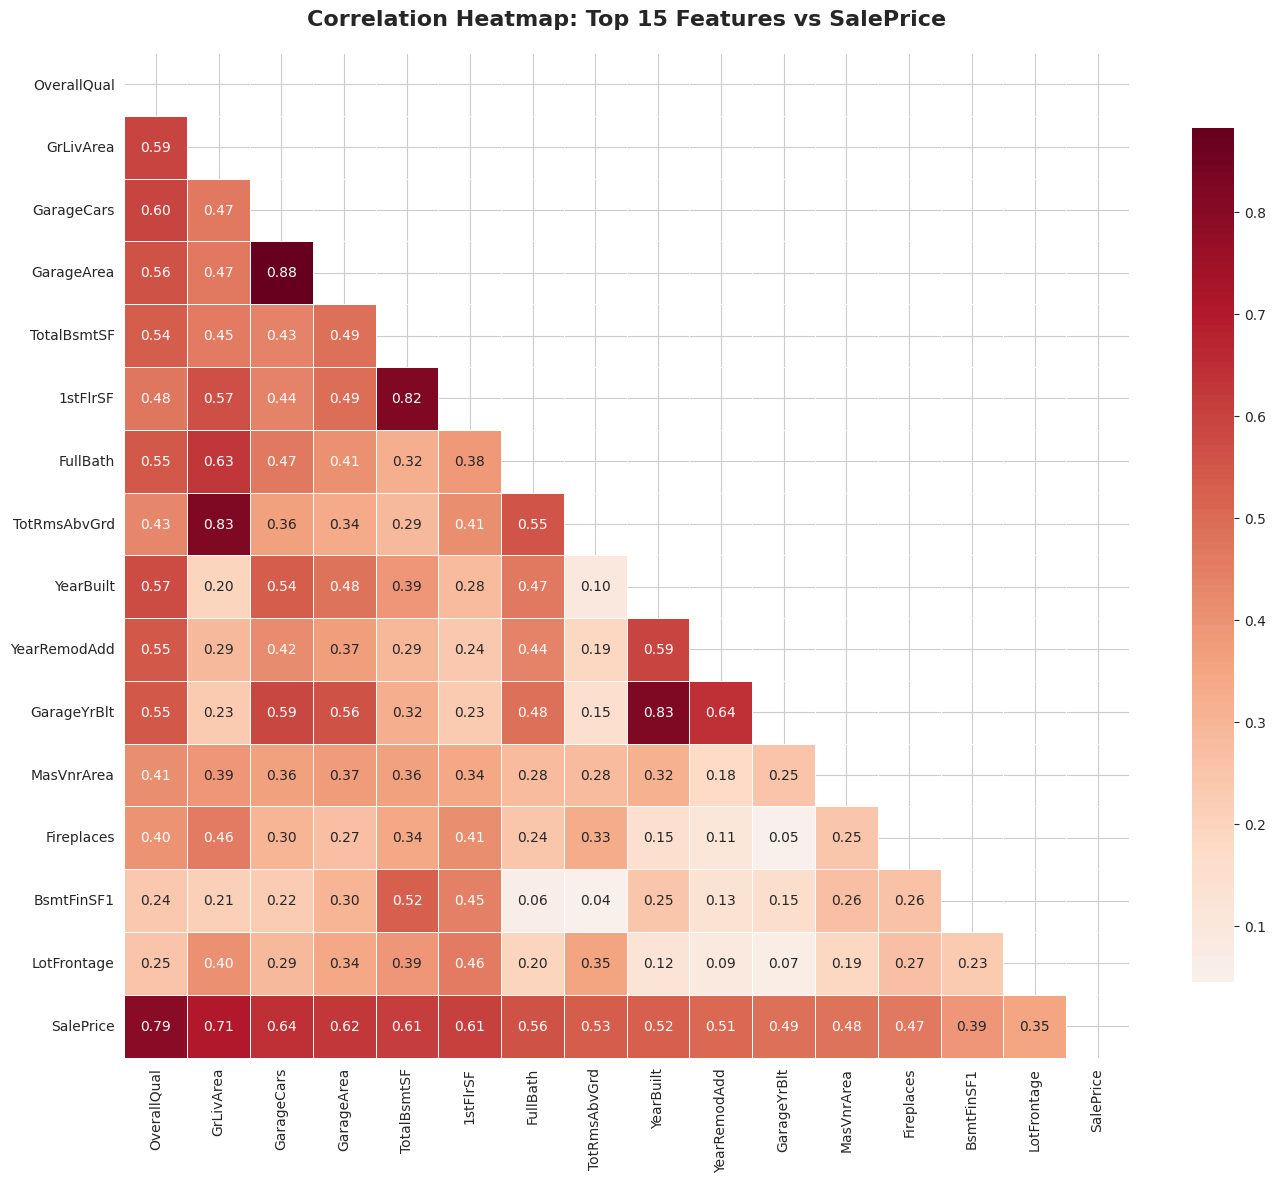

In [11]:
corr_matrix = df[numerical_features.tolist() + ['SalePrice']].corr()
price_correlations = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)

top_features = price_correlations.head(15).index.tolist() + ['SalePrice']
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))
sns.heatmap(top_corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features vs SalePrice', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# У некоторых признаков сильная корреляция друг с другом, например Garage Area и GarageCars, TotalBsmtSF и 1stFlrSF. 

In [12]:
feature_corr = corr_matrix.drop('SalePrice').drop('SalePrice', axis=1)
high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = feature_corr.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], corr_val))

print(f"Highly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
print("\nTop multicollinear pairs:")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f" {feat1} ↔ {feat2}: {corr:.3f}")

Highly correlated feature pairs (|r| > 0.8): 4

Top multicollinear pairs:
 GarageCars ↔ GarageArea: 0.882
 YearBuilt ↔ GarageYrBlt: 0.826
 GrLivArea ↔ TotRmsAbvGrd: 0.825
 TotalBsmtSF ↔ 1stFlrSF: 0.820


In [20]:
outlier_analysis = analyze_outliers_iqr(train)
print(outlier_analysis.head(15))
print()
get_saleprice_bounds(df)
print(f'Максимальное значение: {max(y)}')


          Column  Outliers_Count  Outliers_Pct  Lower_Bound  Upper_Bound  \
4    OverallCond             125          8.61         3.50         7.50   
0     MSSubClass             103          7.10       -55.00       145.00   
6     MasVnrArea              94          6.48      -243.00       405.00   
1    LotFrontage              86          5.93        27.50       111.50   
19   OpenPorchSF              77          5.31      -102.00       170.00   
2        LotArea              75          5.17      1534.75     17488.75   
9    TotalBsmtSF              60          4.14        58.75      2020.75   
13  BedroomAbvGr              35          2.41         0.50         4.50   
18    WoodDeckSF              31          2.14      -252.00       420.00   
14  TotRmsAbvGrd              26          1.79         2.00        10.00   
8      BsmtUnfSF              26          1.79      -657.00      1687.00   
11     GrLivArea              25          1.72       165.75      2731.75   
17    Garage

 Можно привести к распредлению, близкому к нормальному. Я использовал масштобирование, устойчивое к выбросам: x_scaled = (x - медиана) / (Q3 - Q1). Но это не помогает, выбросы всё равно сохраняются и всё равно надо удалять их. Я удалял все выбросы, это плохой подход, удаляется много строк

In [14]:
print(df[df['SalePrice'] > 500000][['SalePrice', 'GrLivArea', 'Neighborhood']])

      SalePrice  GrLivArea Neighborhood
178      501837       2234      StoneBr
440      555000       2402      NridgHt
691      755000       4316      NoRidge
769      538000       3279      StoneBr
803      582933       2822      NridgHt
898      611657       2364      NridgHt
1046     556581       2868      StoneBr
1169     625000       3627      NoRidge
1182     745000       4476      NoRidge


# 1 Изменить структуру репозитория: scr, setup.py убрать, [ ](src/my_project.egg-info) удалить, сделать папку notebooks, удалить тупые ноутбуки кроме последнего
# 2 Добавить readme с описанием структуры проекта - пример на гитхаб
# 3 Научиться пользоваться markdown-любое своё действие в ноутбуке подкреплять записями
# 4 Ответить на все вопросы, которые написаны в телеге
# 5 РАЗОБРАТЬСЯ С ЛИНЕЙНОЙ РЕГРЕССИЕЙ - ФУНКЦИИ ПОТЕРЬ, МЕТРИКИ


In [15]:
df = df[df['SalePrice'] <= 500000]
y_log = np.log1p(df['SalePrice'])
train = df.drop('SalePrice', axis = 1)
train_copy = train.copy()
test_copy = test.copy()

train_copy = train_copy.drop(['GarageCars', 'GarageYrBlt'], axis=1)
test_copy = test_copy.drop(['GarageCars', 'GarageYrBlt'], axis=1)

cat_cols = train_copy.select_dtypes(include=['object']).columns
num_cols = train_copy.select_dtypes(exclude=['object']).columns
train_copy, test_copy = fill_missing_values(train_copy, test_copy)

train_copy, test_copy = transform_skewed_features(train_copy, test_copy, threshold=0.75, auto_lambda=False)



numeric_cols = train_copy.select_dtypes(include=[np.number]).columns.tolist()
scaler = RobustScaler()
train_copy[numeric_cols] = scaler.fit_transform(train_copy[numeric_cols])
test_copy[numeric_cols] = scaler.transform(test_copy[numeric_cols])

train_copy = pd.get_dummies(train_copy)
test_copy = pd.get_dummies(test_copy)
train_copy, test_copy = train_copy.align(test_copy, join='left', axis=1, fill_value=0)

X_train, X_val, y_train, y_val = train_test_split(
    train_copy, y_log, test_size=0.2, random_state=300
)
model = LinearRegression()
model.fit(X_train, y_train)

val_preds_log = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(val_preds_log, y_val))

model1 = Ridge()
model1.fit(X_train, y_train)

val_preds_log1 = model1.predict(X_val)

rmse1 = np.sqrt(mean_squared_error(val_preds_log1, y_val))

print(f"RMSE на валидации: {rmse:.2f}")
print(f"RMSE на валидации: {rmse1:.2f}")






/tmp/ipykernel_16582/2126869699.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_copy.select_dtypes(include=['object']).columns


RMSE на валидации: 0.14
RMSE на валидации: 0.13


In [16]:
final_model = LinearRegression()
final_model.fit(train_copy, y_log) 
test_preds_log = final_model.predict(test_copy) 
test_preds = np.expm1(test_preds_log) 

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_preds})
submission.to_csv('submission.csv', index=False)
print("Файл submission.csv сохранён!")

Файл submission.csv сохранён!


In [17]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, train_copy, y_log, cv=5, 
                         scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print("RMSE на каждом фолде:", rmse_scores)
print("Средний RMSE:", rmse_scores.mean())
print("Стандартное отклонение:", rmse_scores.std())

RMSE на каждом фолде: [0.19185794 0.14627265 0.17352665 0.11470381 0.15920086]
Средний RMSE: 0.1571123832510679
Стандартное отклонение: 0.026065418200612908
